## 1. Setup

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.components.data_ingestion import DataIngestion
from src.components.data_preprocessing import LogPreprocessor

import matplotlib.pyplot as plt

## 2. Load & Prepare Data (same pipeline)

In [2]:
ingestion = DataIngestion()
ingestion.start_spark_session()

df = ingestion.load_data("data/raw/HDFS.log")

preprocessor = LogPreprocessor()
parsed_df = preprocessor.parse_logs(df)

from pyspark.sql.functions import col, concat_ws, to_timestamp

clean_df = parsed_df.filter(
    (parsed_df.date != "") &
    (parsed_df.time != "") &
    (parsed_df.log_level != "")
).withColumn("process_id", col("process_id").cast("int"))

clean_df = clean_df.withColumn(
    "datetime",
    to_timestamp(concat_ws(" ", clean_df.date, clean_df.time), "yyMMdd HHmmss")
)

Resolved path: c:\Users\Priyanshu\Desktop\Main\ML\Distributed-Log-Analysis\data\raw\HDFS.log


# VISUALIZATION STARTS

## 3. Log Level Distribution (Pie Chart)

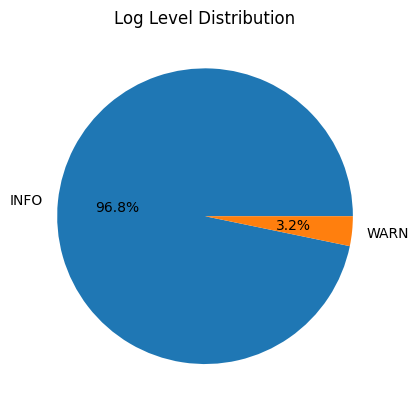

In [3]:
log_level_df = clean_df.groupBy("log_level").count().toPandas()

plt.figure()
plt.pie(log_level_df["count"], labels=log_level_df["log_level"], autopct='%1.1f%%')
plt.title("Log Level Distribution")
plt.show()

## 4. Top Components (Bar Chart)

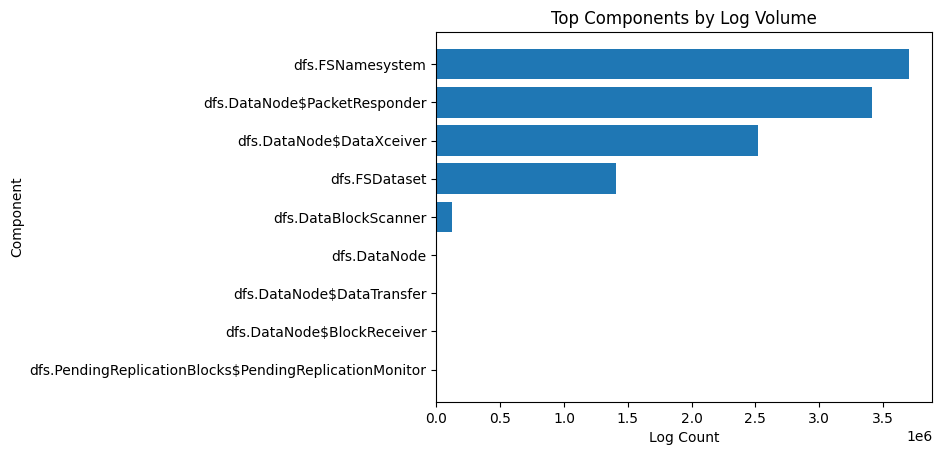

In [4]:
component_df = clean_df.groupBy("component") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure()
plt.barh(component_df["component"], component_df["count"])
plt.title("Top Components by Log Volume")
plt.xlabel("Log Count")
plt.ylabel("Component")
plt.gca().invert_yaxis()
plt.show()

## 5. Warning Components (Failure Indicators)

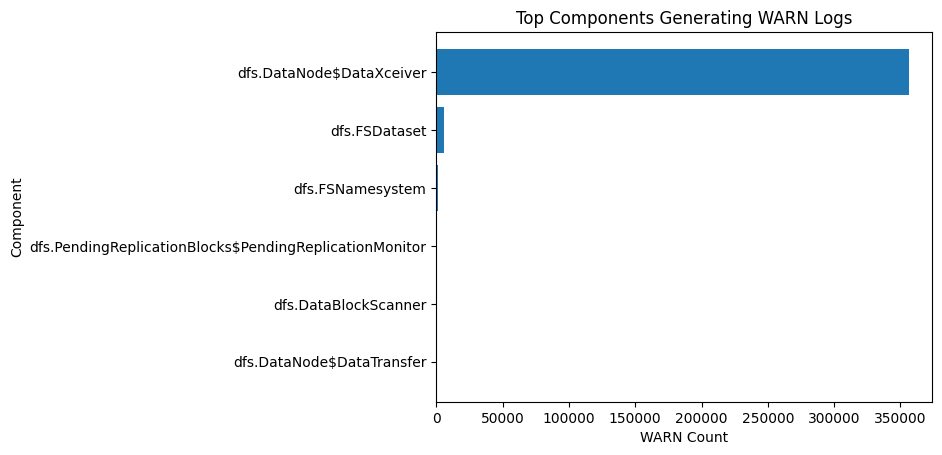

In [5]:
warn_df = clean_df.filter(clean_df.log_level == "WARN")

warn_component_df = warn_df.groupBy("component") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure()
plt.barh(warn_component_df["component"], warn_component_df["count"])
plt.title("Top Components Generating WARN Logs")
plt.xlabel("WARN Count")
plt.ylabel("Component")
plt.gca().invert_yaxis()
plt.show()

## 6. Time-Based Log Activity

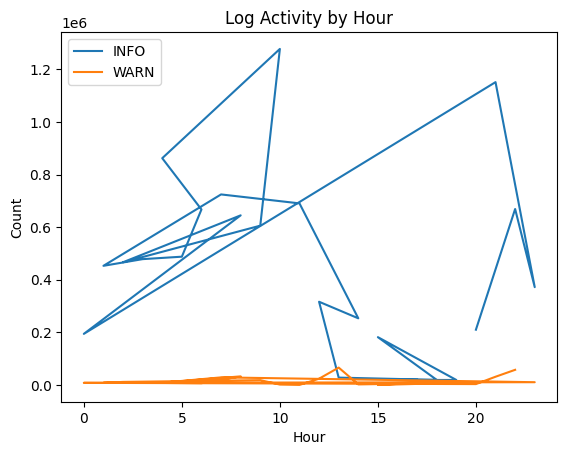

In [6]:
from pyspark.sql.functions import hour

time_df = clean_df.withColumn("hour", hour("datetime")) \
    .groupBy("hour", "log_level") \
    .count() \
    .toPandas()

# Separate INFO and WARN
info_df = time_df[time_df["log_level"] == "INFO"]
warn_df = time_df[time_df["log_level"] == "WARN"]

plt.figure()
plt.plot(info_df["hour"], info_df["count"], label="INFO")
plt.plot(warn_df["hour"], warn_df["count"], label="WARN")

plt.title("Log Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend()
plt.show()

## 7. Failure Trend (WARN spikes)

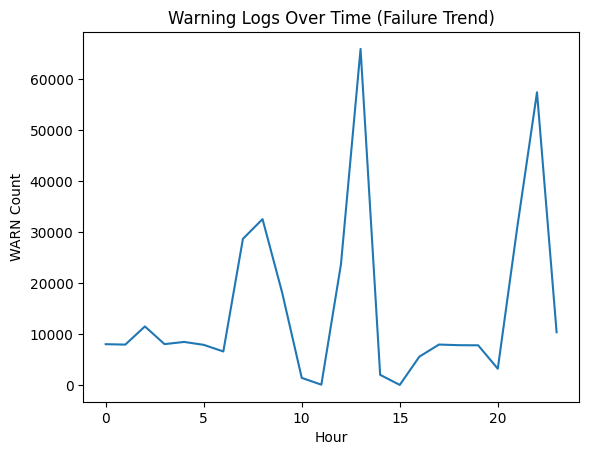

In [7]:
warn_hour_df = clean_df.filter(clean_df.log_level == "WARN") \
    .withColumn("hour", hour("datetime")) \
    .groupBy("hour") \
    .count() \
    .orderBy("hour") \
    .toPandas()

plt.figure()
plt.plot(warn_hour_df["hour"], warn_hour_df["count"])

plt.title("Warning Logs Over Time (Failure Trend)")
plt.xlabel("Hour")
plt.ylabel("WARN Count")
plt.show()

## 8. Top Failure Messages

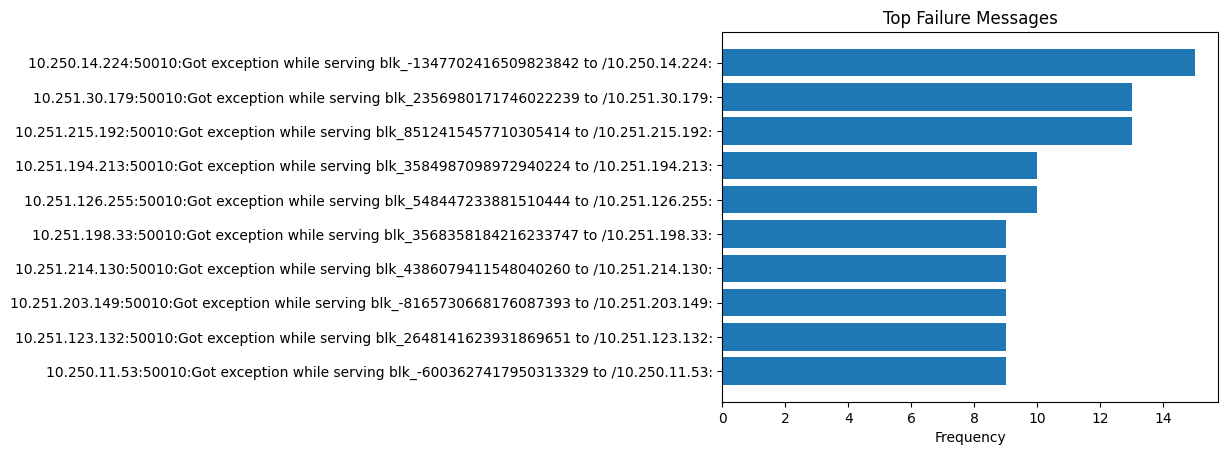

In [8]:
top_msg_df = clean_df.filter(clean_df.log_level == "WARN") \
    .groupBy("message") \
    .count() \
    .orderBy("count", ascending=False) \
    .limit(10) \
    .toPandas()

plt.figure()
plt.barh(top_msg_df["message"], top_msg_df["count"])
plt.title("Top Failure Messages")
plt.xlabel("Frequency")
plt.gca().invert_yaxis()
plt.show()